In [285]:
import pandas as pd
from urllib.parse import urlparse
from Bio import SeqIO
from Bio import AlignIO
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import json
from Bio import Align
import plotly.graph_objects as go
from collections import Counter

### fucntions

In [76]:
# mapping
def mappingBlade2Others(map):
    blade_key = list(map.keys())[0]
    other_key = list(map.keys())[1]
    blade_seq = map[blade_key]
    other_seq = map[other_key]
    df1 = pd.DataFrame(list(blade_seq), columns=['char1'])
    df1['Index'] = df1.index
    df1['count1'] = df1['char1'].apply(lambda x: 1 if x != '.' else 0).cumsum()
    df1['origIDX1'] = df1['count1'] - 1
    
    df2 = pd.DataFrame(list(other_seq), columns=['char2'])
    df2['Index'] = df2.index
    df2['count2'] = df2['char2'].apply(lambda x: 1 if x != '.' else 0).cumsum()
    df2['origIDX2'] = df2['count2'] - 1

    # concat
    df = pd.concat([df1, df2], axis=1)
    return df

def get_otherIdx(df, blade_idx):
    return df[df["origIDX1"]==blade_idx]["origIDX2"].values[0]

def get_otherAlnSeq(df, blade_idx_st, blade_idx_ed):
    
    return df[df["origIDX1"]==blade_idx]["origIDX2"].values[0]

### hPiezo1 blade TM start and end idx

In [64]:
def TMstartend_dff3(fp):
    lst = []
    with open(fp) as f:
        for line in f:
            if line.startswith("Unnamed"):
                segs = line.split()
                if segs[1] == "TMhelix":
                    st = segs[2]
                    end = segs[3]
                    lst.append((int(st), int(end)))
    return lst

In [65]:
TM_st_end_lst = TMstartend_dff3("../DeepTMHMM/blade_deeptmhmm/TMRs.gff3")

In [147]:
TM_st_end_lst

[(6, 25),
 (29, 41),
 (59, 81),
 (121, 138),
 (195, 214),
 (218, 236),
 (245, 266),
 (313, 327),
 (423, 438),
 (441, 456),
 (463, 484),
 (516, 530),
 (575, 594),
 (597, 617),
 (628, 647),
 (680, 696),
 (809, 827),
 (832, 844),
 (854, 872),
 (933, 946),
 (989, 1008),
 (1011, 1026),
 (1041, 1058),
 (1099, 1109),
 (1161, 1179),
 (1182, 1199),
 (1217, 1236),
 (1289, 1298)]

## zoom in THU4 and THU4

In [84]:
# between 345 and 701
blade2cases_df = pd.read_csv("../blade2cases.csv")
blade_seq = blade2cases_df["queries_seq"].tolist()[0]
blade_repeat34_seq = blade_seq[345: 702]
a0a4_seq = blade2cases_df[blade2cases_df["target"]=="AF-A0A482RRZ8-F1-model_v6"]["tSeq"].tolist()[0][412:761]
mgyp_seq = blade2cases_df[blade2cases_df["target"]=="MGYP000926044221"]["tSeq"].tolist()[0]

In [85]:
blade_repeat34_seq

'KGYEARELELAELDQWPQERESDQHVVPTAPDTEADNCIVHELTGQSSVLRRPVRPKRAEPREASPLHSLGHLIMDQSYVCALIAMMVWSITYHSWLTFVLLLWACLIWTVRSRHQLAMLCSPCILLYGMTLCCLRYVWAMDLRPELPTTLGPVSLRQLGLEHTRYPCLDLGAMLLYTLTFWLLLRQFVKEKLLKWAESPAALTEVTVADTEPTRTQTLLQSLGELVKGVYAKYWIYVCAGMFIVVSFAGRLVVYKIVYMFLFLLCLTLFQVYYSLWRKLLKAFWWLVVAYTMLVLIAVYTFQFQDFPAYWRNLTGFTDEQLGDLGLEQFSVSELFSSILVPGFFLLACILQLHYFH'

In [86]:
a0a4_seq

'PTLSVTSCNSRLTPTSPPVYAPVSPNAAYISHQNSSVQLLLLGQGKLGVVVALLAKQWVLVTLALLYGLSLSHVDVVHAGYVVFFVWFATQAKHRRDYWPLLVAYCVLAICIMFMWDVTTWALPDTRANIPPWIVGPNIPNPTVDLWHSTFATNMLVFGVAVLQAPLYQAPLRDAARARMREAKESARDFRRQWQHAKFVIAHYSPRLVILICFGICLIPPITFNSVISLSLTFVLALLHLLMSQEQAGDLARHHAGRPNCRCMRSARLFATFSIVEGVILGLRYMYQFESGQEALDNTIGALFRNWMPMRDVGFWRYVDASYNGSVYLQLLDTAALMVVTAVQWHLLV'

In [87]:
mgyp_seq

'PTTDYIFVELPLQVIERASLVVVIVIILLSSLQPPTVMTLFSLVDVIGILFITALNVDNISRRYIWTRRWVSVWILIEGLCLVILYLYQFDAVAQFFYDARGLPQKCNWTISDQSVWQCTRINSTWVTFSDLGLREFESSGASRLAVAFGMFYNCVSFVALLILFISVGRKLEKHRLVSGDSFGSEADYYQLLDDEVAPMRDVAVAVGSNVRSQCAEVTHTIVVALKYFCYTHGGKMGIIAAVIICGSDVCAFQFILLLLLCALVICTGKQTVAGGGTPIFSKAWSVIFVCGAIRSVLTILFQFNSVYYHVAVPYSDDTTWAGLRVAWVSRGMKVPKLSNPERATMMQMWAAMQESIYLILIGFLMKMSLEFRPAAREFSVLWKSFRAQENISAGGEERENDGETKGEELHGSDEPTFHRRSGAFCFHFGS'

## sequence similarity via emboss_water

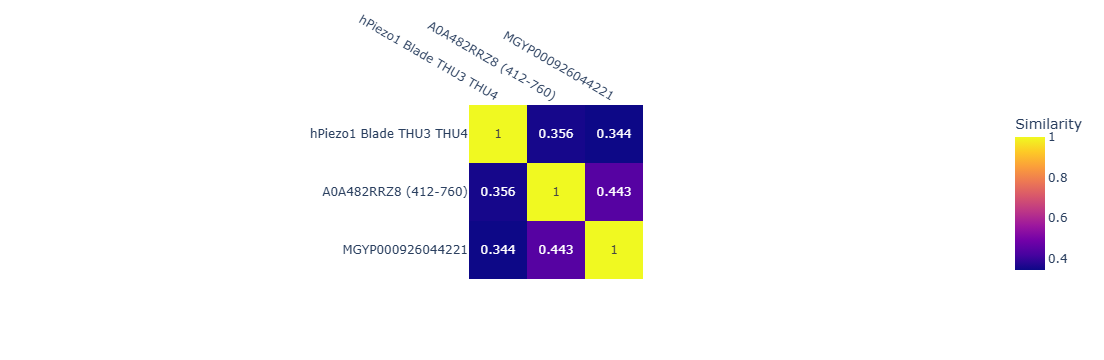

In [16]:
data=[[1, 0.356, 0.344], 
      [0.356, 1, 0.443], 
      [0.344, 0.443, 1]]
fig = px.imshow(data,
                labels=dict(x="", y="", color="Similarity"),
                x=['hPiezo1 Blade THU3 THU4', 'A0A482RRZ8 (412-760)', 'MGYP000926044221'],
                y=['hPiezo1 Blade THU3 THU4', 'A0A482RRZ8 (412-760)', 'MGYP000926044221'],
                text_auto=True
               )
fig.update_xaxes(side="top")
fig.show()

## structure similarity

In [3]:
# chimeraX
a0a4_chimeraX_map = {}
a0a4_chimeraX_fp = "../chimeraXalign/a0a4chimeraX.fasta"
mgyp_chimeraX_map = {}
mgyp_chimeraX_fp = "../chimeraXalign/mgypchimeraX.fasta"
for record in SeqIO.parse(a0a4_chimeraX_fp, "fasta"):
    a0a4_chimeraX_map[record.id] = str(record.seq)
for record in SeqIO.parse(mgyp_chimeraX_fp, "fasta"):
    mgyp_chimeraX_map[record.id] = str(record.seq)

In [78]:
a0a4_df = mappingBlade2Others(a0a4_chimeraX_map)
mgyp_df = mappingBlade2Others(mgyp_chimeraX_map)

In [79]:
# Blade between 345 and 701

In [81]:
get_otherIdx(a0a4_df, 345), get_otherIdx(a0a4_df, 701) # > 411 - 760

(411, 760)

In [80]:
get_otherIdx(mgyp_df, 345), get_otherIdx(mgyp_df, 701) # > 0-375

(-1, 375)

## amino acide per aligned TM

In [289]:
def get_AlnSeq2(df, blade_idx_st, blade_idx_ed):
    selected_rows = df[(df['origIDX1'] >= blade_idx_st) & (df['origIDX1'] <= blade_idx_ed)& (df['char1'] != ".")]
    blade_s = ''.join(selected_rows['char1'])
    other_s = ''.join(selected_rows['char2'])
    return blade_s, other_s

In [125]:
# TM_st_end_lst
THU_st_ed = {
    "THU3_1": (423, 438),
    "THU3_2": (441, 456),
    "THU3_3": (463, 484),
    "THU3_4": (516, 530),
    "THU4_1": (575, 594),
    "THU4_2": (597, 617),
    "THU4_3": (628, 647),
    "THU4_4": (680, 696),
}

In [290]:
# A0A4
for THU_name, blade_range in THU_st_ed.items():
    blade_s, other_s = get_AlnSeq2(a0a4_df, blade_range[0], blade_range[1])
    seq_dict = {
        THU_name: blade_s,
        "A0A4": other_s
    }
    
    for name, seq in seq_dict.items():
        print(f">{name}\n{seq}")
    print("===============================")

>THU3_1
YVCALIAMMVWSITYH
>A0A4
VLVTLALLYGLSLSHV
>THU3_2
LTFVLLLWACLIWTVR
>A0A4
VHAGYVVFFVWFAT.Q
>THU3_3
MLCSPCILLYGMTLCCLRYVWA
>A0A4
Y..WPLLVAYCVLAICIMFMWD
>THU3_4
GAMLLYTLTFWLLLR
>A0A4
GVAVLQAPLYQAPLR
>THU4_1
YAKYWIYVCAGMFIVVSFAG
>A0A4
SPRLVILICFGICLIPPITF
>THU4_2
VVYKIVYMFLFLLCLTLFQVY
>A0A4
VISLSLTFVLALLHLLMSQEN
>THU4_3
FWWLVVAYTMLVLIAVYTFQ
>A0A4
ATFSIVEGVILGLRYMYQ..
>THU4_4
FSSILVPGFFLLACILQ
>A0A4
YLQLLDTAALMVVTAVQ


In [291]:
# mgyp
for THU_name, blade_range in THU_st_ed.items():
    blade_s, other_s = get_AlnSeq2(mgyp_df, blade_range[0], blade_range[1])
    seq_dict = {
        THU_name: blade_s,
        "mgyp": other_s
    }
    
    for name, seq in seq_dict.items():
        print(f">{name}\n{seq}")
    print("===============================")

>THU3_1
YVCALIAMMVWSITYH
>mgyp
SLVVVIVIILLSSLQP
>THU3_2
LTFVLLLWACLIWTVR
>mgyp
FSLVDVIGILFITALN
>THU3_3
MLCSPCILLYGMTLCCLRYVWA
>mgyp
RRWVSVWILIEGLCLVILYLYQ
>THU3_4
GAMLLYTLTFWLLLR
>mgyp
VSFVALLILFISVGR
>THU4_1
YAKYWIYVCAGMFIVVSFAG
>mgyp
YFCYTHGGKMGIIAAVIICG
>THU4_2
VVYKIVYMFLFLLCLTLFQVY
>mgyp
VQFILLLLLCALVICTGKQTV
>THU4_3
FWWLVVAYTMLVLIAVYTFQ
>mgyp
AWSVIFVCGAIRSVLTILFQ
>THU4_4
FSSILVPGFFLLACILQ
>mgyp
ESIYLILIGFLMKMSLE


## parse MSA

In [158]:
with open("./clustalo-I20260105-113912-0847-62383534-p1m.aln-clustal_num", 'r') as file:
    lines = file.readlines()
# names
Name_lst = []
for line in lines[1:]:
    parts = line.split()
    if len(parts) >= 2:
        name = parts[0].strip()  # Sequence name
        Name_lst.append(name)

In [161]:
len(list(set(Name_lst)))

31

In [162]:
MSA_dict = {}
for name in set(Name_lst):
    MSA_dict[name] = []
for line in lines[1:]:
    for name in list(set(Name_lst)):
        if line.startswith(name):
            seq_part=line.split()[1]
            MSA_dict[name].append(seq_part)

In [173]:
data_dict={}
Q92508_orig_Idx=[]
for k, v in MSA_dict.items():
    full_seq = "".join(v)
    data_dict[k] = list(full_seq)

Q92508_gap_lst=[]
c=0
for i in data_dict["sp|Q92508|PIEZ1_HUMAN"]:
    if i =="-":
        Q92508_gap_lst.append(None)
    else:
        Q92508_gap_lst.append(c)
        c+=1

msa_df=pd.DataFrame(data_dict)
msa_df["Q92508_IDX"]=Q92508_gap_lst

In [177]:
msa_df

,KRX01930.1,sp|M9MSG8|PIEZO_DROME,XP_024369685.1,tr|F1KPQ0|F1KPQ0_ASCSU,tr|H2J7Z5|H2J7Z5_MARPK,KHN03769.1,6B3R_1|Chains,sp|Q99750|MDFI_HUMAN,CEL94374.1,CUG89832.1,...,sp|Q92508|PIEZ1_HUMAN,6LQI_1|Chains,EWM21785.1,sp|B9EJG8|T150C_HUMAN,sp|A0A061ACU2|PIEZ1_CAEEL,tr|A0D620|A0D620_PARTE,sp|O14672|ADA10_HUMAN,tr|C4LXG0|C4LXG0_ENTHI,tr|H2J8A7|H2J8A7_MARPK,Q92508_IDX
0,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,NaN
1,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,NaN
2,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,NaN
3,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,NaN
4,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6067,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,NaN
6068,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,NaN
6069,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,NaN
6070,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,NaN


In [175]:
THU_st_ed

{'THU3_1': (423, 438),
 'THU3_2': (441, 456),
 'THU3_3': (463, 484),
 'THU3_4': (516, 530),
 'THU4_1': (575, 594),
 'THU4_2': (597, 617),
 'THU4_3': (628, 647),
 'THU4_4': (680, 696)}

## VIZ together

In [214]:
# pip install pymsaviz
from pymsaviz import MsaViz, get_msa_testdata
from io import StringIO

In [292]:
## A0A4
for THU_name, blade_range in THU_st_ed.items():
    blade_s, other_s = get_AlnSeq2(a0a4_df, blade_range[0], blade_range[1])
    THU_idx, TM_idx=THU_name.split("_")[0], THU_name.split("_")[1]
    seq_dict = {
        "hPiezo1": blade_s,
        "A0A482RRZ8": other_s
    }
    MSA2_SEQ = "\n".join(f">{name}\n{seq}" for name, seq in seq_dict.items())
    msa_file = StringIO(MSA2_SEQ)
    mv = MsaViz(msa_file, wrap_length=50, color_scheme="Clustal", show_count=False, show_grid=True, show_consensus=False)
    mv.set_plot_params(ticks_interval=5,x_unit_size=0.14,grid_color="black")
    mv.set_highlight_pos_by_ident_thr(min_thr=90, max_thr=100)
    mv.add_text_annotation((1, len(blade_s)), "hPiezo1_"+THU_idx+"_TM"+TM_idx, text_color="black", range_color="black")
    # fig = mv.plotfig()
    file_name ="A0A482RRZ8_"+"hPiezo1_"+THU_idx+"_TM"+TM_idx
    mv.savefig("./LOGO_nogap/"+file_name+".svg")
    


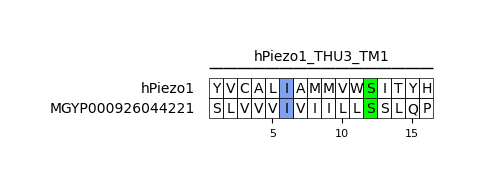

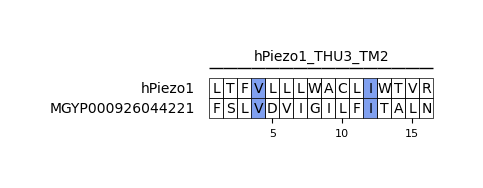

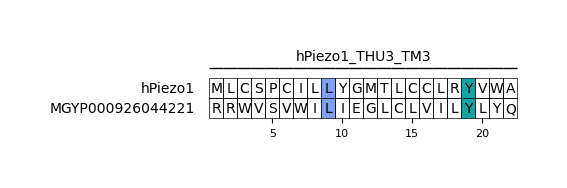

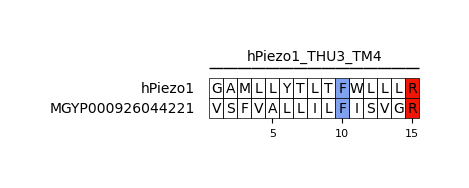

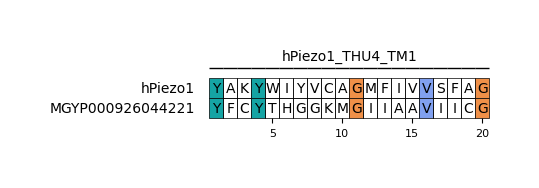

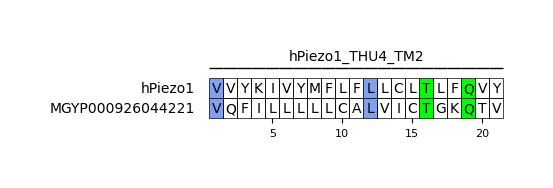

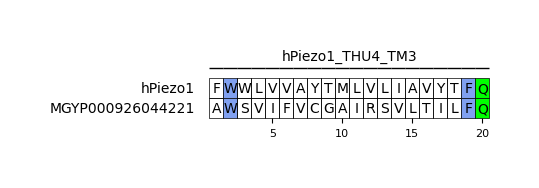

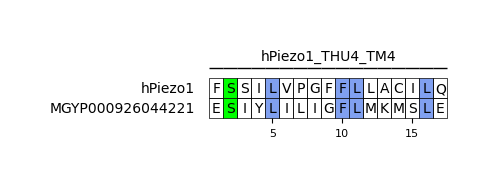

In [293]:
## MGYP
for THU_name, blade_range in THU_st_ed.items():
    blade_s, other_s = get_AlnSeq2(mgyp_df, blade_range[0], blade_range[1])
    THU_idx, TM_idx=THU_name.split("_")[0], THU_name.split("_")[1]
    seq_dict = {
        "hPiezo1": blade_s,
        "MGYP000926044221": other_s
    }
    MSA2_SEQ = "\n".join(f">{name}\n{seq}" for name, seq in seq_dict.items())
    msa_file = StringIO(MSA2_SEQ)
    mv = MsaViz(msa_file, wrap_length=50, color_scheme="Clustal", show_count=False, show_grid=True, show_consensus=False)
    mv.set_plot_params(ticks_interval=5,x_unit_size=0.14,grid_color="black")
    mv.set_highlight_pos_by_ident_thr(min_thr=90, max_thr=100)
    mv.add_text_annotation((1, len(blade_s)), "hPiezo1_"+THU_idx+"_TM"+TM_idx, text_color="black", range_color="black")
    # fig = mv.plotfig()
    file_name ="MGYP000926044221_"+"hPiezo1_"+THU_idx+"_TM"+TM_idx
    mv.savefig("./LOGO_nogap/"+file_name+".svg")
    fig = mv.plotfig()

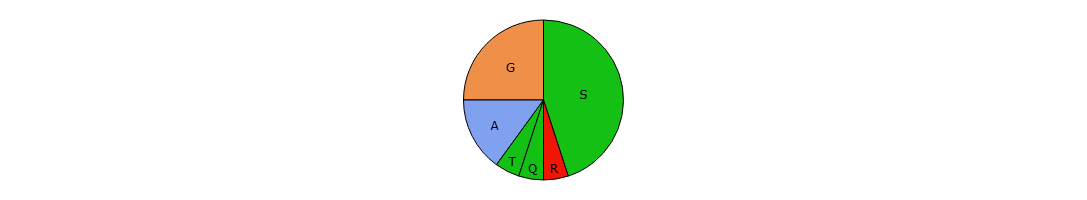

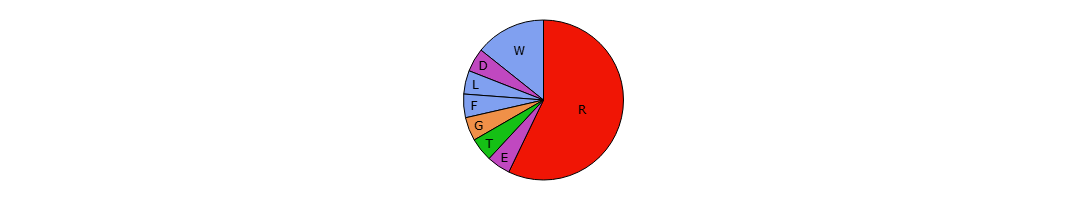

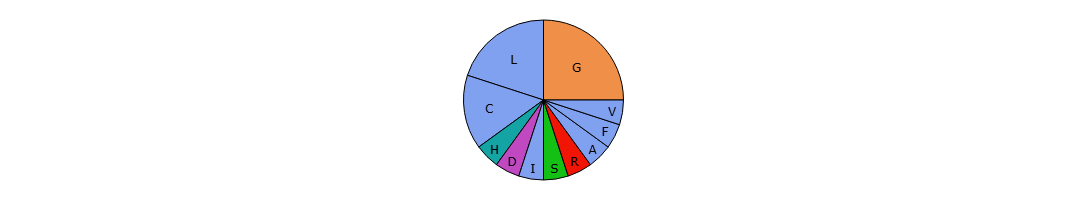

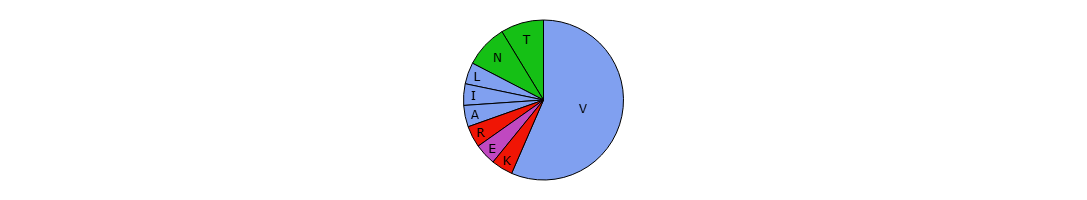

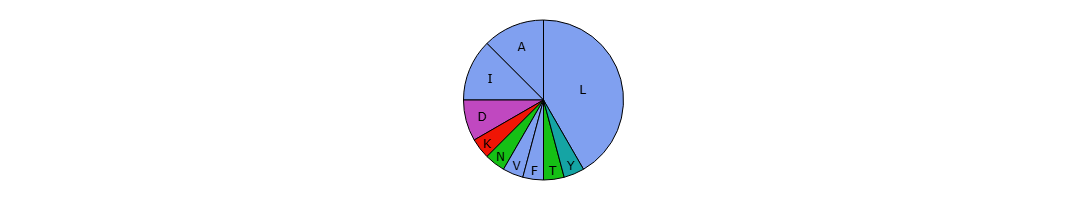

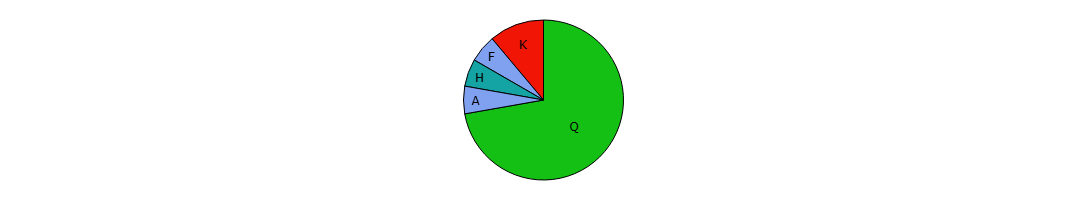

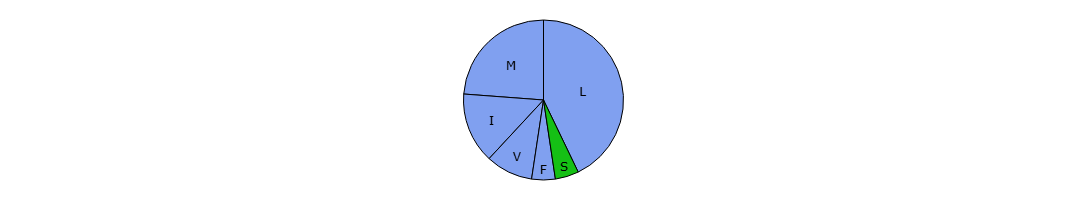

In [321]:
## msa
# for THU_name, blade_range in THU_st_ed.items():
#     sub_df = msa_df[(msa_df['Q92508_IDX'] >= blade_range[0]) & (msa_df['Q92508_IDX'] <= blade_range[1])]
#     THU_idx, TM_idx=THU_name.split("_")[0], THU_name.split("_")[1]
    
    # S_dict={}
    # for column in sub_df.columns[:-1]:
    #     S_dict[column]="".join(sub_df[column])
    
    # MSA_SEQ = "\n".join(f">{name}\n{seq}" for name, seq in S_dict.items())
    # msa_file = StringIO(MSA_SEQ)
    # mv = MsaViz(msa_file, wrap_length=50, color_scheme="Clustal", show_count=False, show_grid=True, show_consensus=True)
    # mv.add_text_annotation((1, len(sub_df)), "hPiezo1_"+THU_idx+"_TM"+TM_idx, text_color="black", range_color="black")
    # mv.set_plot_params(ticks_interval=5,x_unit_size=0.14,grid_color="black")
    # file_name="hPiezo1_"+THU_idx+"_TM"+TM_idx
    # mv.savefig("./LOGO_nogap/"+file_name+".svg")
    # fig = mv.plotfig()

clustalX_color_dict={
    "A":"#80A0F0",
    "C":"#80A0F0",
    "I":"#80A0F0",
    "L":"#80A0F0",
    "M":"#80A0F0",
    "F":"#80A0F0",
    "W":"#80A0F0",
    "V":"#80A0F0",
    "K":"#F01505",
    "R":"#F01505",
    "E":"#C048C0",
    "D":"#C048C0",
    "N":"#15C015",
    "Q":"#15C015",
    "S":"#15C015",
    "T":"#15C015",
    "G":"#F09048",
    "P":"#C0C000",
    "H":"#15A4A4",
    "Y":"#15A4A4",   
    "-":"#FFFFFF"
}
C_85_color="#F08080"

for pos in [434, 530, 585, 597, 608, 615, 695]:
    colr=[]
    row= msa_df[msa_df['Q92508_IDX'] == pos]
    lst_all = row.iloc[0].tolist()[:-1]
    lst = [i for i in lst_all if i != "-"]
    freq = Counter(lst)
    freq_d=dict(freq)
    for k,v in freq_d.items():
        if k == "C":
            percentage = v/len(lst)
            if percentage>0.85:
                colr.append(C_85_color)
            else:
                colr.append("#80A0F0")
        colr.append(clustalX_color_dict[k])
        
    figPie = go.Figure(data=[go.Pie(labels=list(freq.keys()), values=list(freq.values()), textinfo='label',textfont=dict(color='black'),
                                    marker=dict(colors=colr,
                                                line=dict(
                                                    color='black',
                                                    width=1
                                                )))])

    figPie.update_layout(
        showlegend=False,
        height=200, width=200,
        paper_bgcolor="rgba(0,0,0,0)",
        plot_bgcolor="rgba(0,0,0,0)",
        margin=dict(l=20, r=20, t=20, b=20),
    )
    figPie.write_image("./pie/"+str(pos)+"_pie.svg")
    figPie.show()
            
            
        
    
# 434, 530, 585, 597, 608, 615, 695

In [332]:
## PDB to Fasta
def change_char_at_index(original_string, index, new_char):
    string_list = list(original_string)
    string_list[index] = new_char
    modified_string = ''.join(string_list)
    return modified_string

In [334]:
from Bio import PDB
parser = PDB.PPBuilder()
structure = PDB.PDBParser(QUIET=True).get_structure('protein', './blade1_1304_thu34.pdb')
for model in structure:
    for chain in model:
        ppb = parser.build_peptides(chain)
        for pp in ppb:
            sequence = pp.get_sequence()
blade1_1304_thu34_seq = str(sequence)
blade1_1304_thu34_seq

'KGYEARELELAELDQWPQERESDQHVVPTAPDTEADNCIVHELTGQSSVLRRPVRPKRAEPREASPLHSLGHLIMDQSYVCALIAMMVWSITYHSWLTFVLLLWACLIWTVRSRHQLAMLCSPCILLYGMTLCCLRYVWAMDLRPELPTTLGPVSLRQLGLEHTRYPCLDLGAMLLYTLTFWLLLRQFVKEKLLKWAESPAALTEVTVADTEPTRTQTLLQSLGELVKGVYAKYWIYVCAGMFIVVSFAGRLVVYKIVYMFLFLLCLTLFQVYYSLWRKLLKAFWWLVVAYTMLVLIAVYTFQFQDFPAYWRNLTGFTDEQLGDLGLEQFSVSELFSSILVPGFFLLACILQLHYF'

In [337]:
## 531 R TO C
R531C_seq = change_char_at_index(blade1_1304_thu34_seq, 531-346, "C")
## 598 V TO M
V598M_seq = change_char_at_index(blade1_1304_thu34_seq, 598-346, "M")

In [338]:
R531C_seq

'KGYEARELELAELDQWPQERESDQHVVPTAPDTEADNCIVHELTGQSSVLRRPVRPKRAEPREASPLHSLGHLIMDQSYVCALIAMMVWSITYHSWLTFVLLLWACLIWTVRSRHQLAMLCSPCILLYGMTLCCLRYVWAMDLRPELPTTLGPVSLRQLGLEHTRYPCLDLGAMLLYTLTFWLLLCQFVKEKLLKWAESPAALTEVTVADTEPTRTQTLLQSLGELVKGVYAKYWIYVCAGMFIVVSFAGRLVVYKIVYMFLFLLCLTLFQVYYSLWRKLLKAFWWLVVAYTMLVLIAVYTFQFQDFPAYWRNLTGFTDEQLGDLGLEQFSVSELFSSILVPGFFLLACILQLHYF'

In [342]:
V598M_seq

'KGYEARELELAELDQWPQERESDQHVVPTAPDTEADNCIVHELTGQSSVLRRPVRPKRAEPREASPLHSLGHLIMDQSYVCALIAMMVWSITYHSWLTFVLLLWACLIWTVRSRHQLAMLCSPCILLYGMTLCCLRYVWAMDLRPELPTTLGPVSLRQLGLEHTRYPCLDLGAMLLYTLTFWLLLRQFVKEKLLKWAESPAALTEVTVADTEPTRTQTLLQSLGELVKGVYAKYWIYVCAGMFIVVSFAGRLMVYKIVYMFLFLLCLTLFQVYYSLWRKLLKAFWWLVVAYTMLVLIAVYTFQFQDFPAYWRNLTGFTDEQLGDLGLEQFSVSELFSSILVPGFFLLACILQLHYF'